# Flight Events Table Exploration

Notebook to inspect and visualize `flight_events` from `db/flight_events.duckdb`.


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect('../db/flight_events.duckdb')


In [5]:
# Lists the Tables
con.execute('SHOW TABLES').fetchdf()


,name
0,flight_events
1,flight_events_raw


In [6]:
# Describes the Table
con.execute("DESCRIBE flight_events").fetchdf()


,column_name,column_type,null,key,default,extra
0,address,VARCHAR,YES,None,None,None
1,altitude,INTEGER,YES,None,None,None
2,callsign,VARCHAR,YES,None,None,None
3,flight_date,DATE,YES,None,None,None
4,destination_iata,VARCHAR,YES,None,None,None
5,destination_icao,VARCHAR,YES,None,None,None
6,equipment,VARCHAR,YES,None,None,None
7,event,VARCHAR,YES,None,None,None
8,flight,VARCHAR,YES,None,None,None
9,flight_id,BIGINT,YES,None,None,None


In [7]:
# Preview rows
df = con.execute('SELECT * FROM flight_events LIMIT 20').fetchdf()
df


,address,altitude,callsign,flight_date,destination_iata,destination_icao,equipment,event,flight,flight_id,latitude,longitude,operator,origin_iata,origin_icao,registration,flight_time,flight_timestamp,filename
0,A91A81,525,N686LF,2022-10-03,PDX,KPDX,A119,landed,NaN,766465831,45.49905,-122.68537,NaN,NaN,NaN,N686LF,02:36:55,2022-10-03 02:36:55,data/2022-10-03.csv
1,ABAF47,37850,FDX197,2022-10-03,HNL,PHNL,B77L,descent,FX197,766473984,21.88715,-156.09874,FDX,MEM,KMEM,N852FD,02:50:10,2022-10-03 02:50:10,data/2022-10-03.csv
2,ABAF47,0,FDX197,2022-10-03,HNL,PHNL,B77L,landed,FX197,766473984,21.32531,-157.92453,FDX,MEM,KMEM,N852FD,03:16:57,2022-10-03 03:16:57,data/2022-10-03.csv
3,ABAF47,0,FDX197,2022-10-03,HNL,PHNL,B77L,gate_arrival,FX197,766473984,21.32529,-157.92233,FDX,MEM,KMEM,N852FD,03:17:12,2022-10-03 03:17:12,data/2022-10-03.csv
4,7C8067,0,QFA6,2022-10-03,PER,YPPH,B789,landed,QF6,766481217,-31.93658,115.96612,QFA,FCO,LIRF,VH-ZND,00:21:32,2022-10-03 00:21:32,data/2022-10-03.csv
5,7C8067,0,QFA6,2022-10-03,PER,YPPH,B789,gate_arrival,QF6,766481217,-31.93496,115.96535,QFA,FCO,LIRF,VH-ZND,00:22:02,2022-10-03 00:22:02,data/2022-10-03.csv
6,7C806E,39725,QFA9,2022-10-03,LHR,EGLL,B789,descent,QF9,766481849,51.48701,2.92259,QFA,PER,YPPH,VH-ZNK,03:54:57,2022-10-03 03:54:57,data/2022-10-03.csv
7,7C806E,0,QFA9,2022-10-03,LHR,EGLL,B789,landed,QF9,766481849,51.46500,-0.45406,QFA,PER,YPPH,VH-ZNK,04:25:34,2022-10-03 04:25:34,data/2022-10-03.csv
8,7C806E,0,QFA9,2022-10-03,LHR,EGLL,B789,gate_arrival,QF9,766481849,51.46558,-0.45153,QFA,PER,YPPH,VH-ZNK,04:25:49,2022-10-03 04:25:49,data/2022-10-03.csv
9,71C360,37425,AAR2513,2022-10-03,ICN,RKSI,A359,descent,OZ2513,766489649,35.96584,129.58047,AAR,ATL,KATL,HL8360,00:40:13,2022-10-03 00:40:13,data/2022-10-03.csv


### Show number of rows and date range

In [8]:

con.execute('''
SELECT COUNT(*) AS rows,
       MIN(flight_date) AS min_date,
       MAX(flight_date) AS max_date
FROM flight_events
''').fetchdf()


,rows,min_date,max_date
0,700000,2022-10-03,2022-10-09


### Which values are Null?

In [9]:
con.execute('''
SELECT
    SUM(CASE WHEN origin_iata IS NULL OR origin_iata = '' THEN 1 ELSE 0 END) AS missing_origin_iata,
    SUM(CASE WHEN destination_iata IS NULL OR destination_iata = '' THEN 1 ELSE 0 END) AS missing_destination_iata,
    SUM(CASE WHEN equipment IS NULL OR equipment = '' THEN 1 ELSE 0 END) AS missing_equipment,
    SUM(CASE WHEN registration IS NULL OR registration = '' THEN 1 ELSE 0 END) AS missing_registration
FROM flight_events
''').fetchdf()


,missing_origin_iata,missing_destination_iata,missing_equipment,missing_registration
0,41930.0,41700.0,6410.0,5248.0


### Plot number of flights per day (estimation, as rows without flight numbers are treated as unique flights)

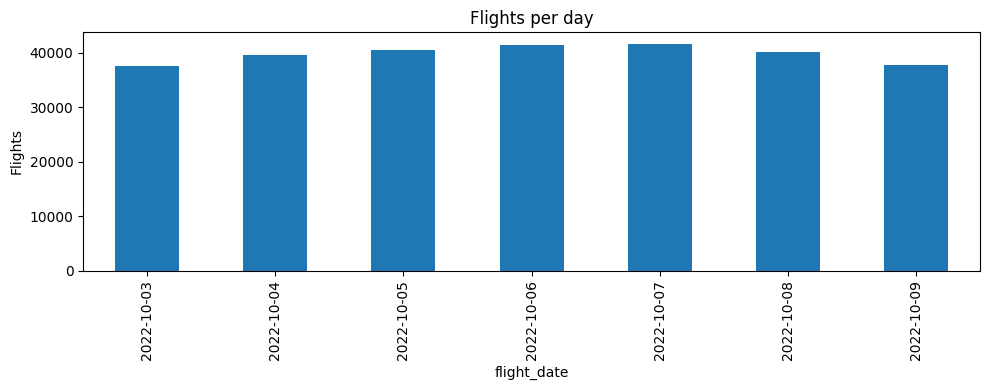

In [13]:
daily = con.execute('''
SELECT
    flight_date,
    COUNT(DISTINCT flight_key) AS flights
FROM (
    SELECT
        flight_date,
        COALESCE(flight, 'dummy_' || CAST(row_number() OVER () AS VARCHAR)) AS flight_key
    FROM flight_events
)
GROUP BY flight_date
ORDER BY flight_date
''').fetchdf()

daily["flight_date"] = daily["flight_date"].astype(str)

daily.plot(x='flight_date', y='flights', kind='bar', figsize=(10, 4), legend=False)
plt.ylabel('Flights')
plt.title('Flights per day')
plt.tight_layout()
plt.show()


### Flight ID nullcheck:

In [20]:
con.execute('''
SELECT
    COUNT(*) AS total_rows,
    COUNT(flight_id) AS non_null_flight_id,
    COUNT(*) - COUNT(flight_id) AS null_flight_id
FROM flight_events
''').fetchdf()

,total_rows,non_null_flight_id,null_flight_id
0,700000,550423,0


### Show most frequent routes:

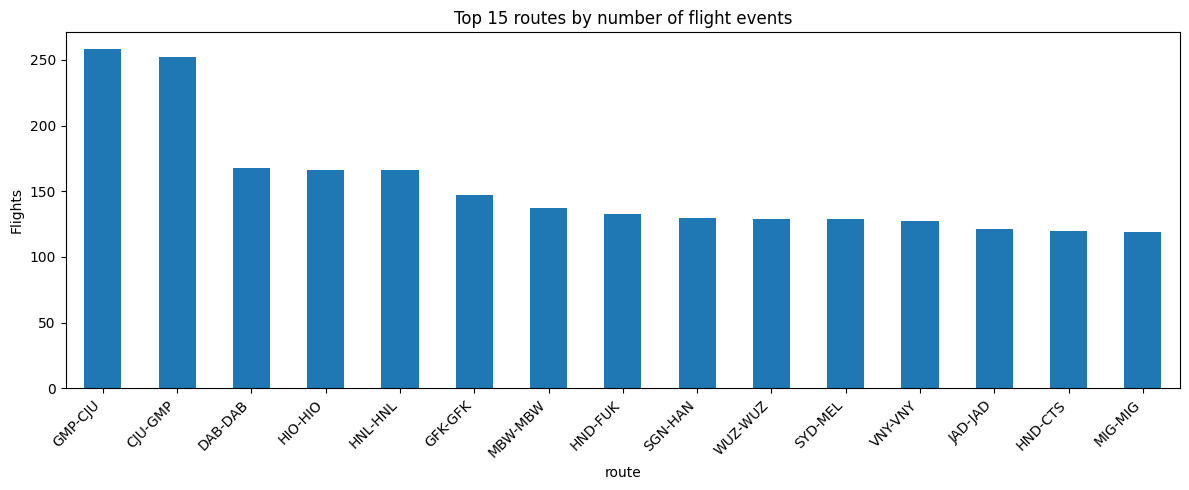

In [21]:
routes = con.execute('''
SELECT
    origin_iata || '-' || destination_iata AS route,
    COUNT(DISTINCT flight_id) AS flights
FROM flight_events
WHERE origin_iata IS NOT NULL
  AND destination_iata IS NOT NULL
GROUP BY route
ORDER BY flights DESC
LIMIT 15
''').fetchdf()

routes.plot(x='route', y='flights', kind='bar', figsize=(12, 5), legend=False)
plt.ylabel('Flights')
plt.title('Top 15 routes by number of flight events')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Show max frequency aircraft types:

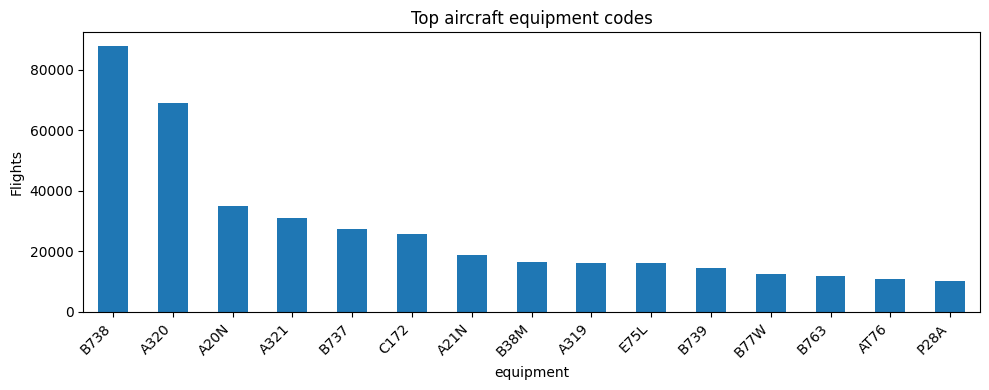

In [23]:
equip = con.execute('''
SELECT equipment, COUNT(*) AS flights
FROM flight_events
WHERE equipment IS NOT NULL AND equipment <> ''
GROUP BY equipment
ORDER BY flights DESC
LIMIT 15
''').fetchdf()

equip.plot(x='equipment', y='flights', kind='bar', figsize=(10, 4), legend=False)
plt.ylabel('Flights')
plt.title('Top aircraft equipment codes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
example = con.execute('''
SELECT
    flight_date,
    origin_iata,
    destination_iata,
    equipment,
    COUNT(*) AS flights
FROM flight_events
GROUP BY 1,2,3,4
ORDER BY flight_date, flights DESC
LIMIT 25
''').fetchdf()
example


,flight_date,origin_iata,destination_iata,equipment,flights
0,2022-10-03,NaN,NaN,C172,328
1,2022-10-03,NaN,NaN,AS50,123
2,2022-10-03,NaN,NaN,NaN,102
3,2022-10-03,NaN,NaN,EC35,98
4,2022-10-03,NaN,NaN,P28A,91
5,2022-10-03,NaN,MLE,DHC6,90
6,2022-10-03,NaN,NaN,DA40,89
7,2022-10-03,NaN,NaN,PC21,81
8,2022-10-03,SYD,MEL,B738,76
9,2022-10-03,NaN,NaN,B407,75


: 